# Road Segmentation from Satellite Images

Given a satellite image as input, output a pixel-wise mask indicating the roads

## Dataset - Massachusetts Roads Dataset

https://www.kaggle.com/datasets/balraj98/massachusetts-roads-dataset

- 1171 aerial images, each 1500x1500 pixels covering 2.25 sq km.
- Urban, suburban, and rural regions ( varying road network density)
- Background - black, road - white

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tvm
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
cv2.utils.logging.setLogLevel(cv2.utils.logging.LOG_LEVEL_ERROR)

3

In [3]:
DATA_DIR = '../input/datasets/balraj98/massachusetts-roads-dataset/tiff/'

x_train_dir = os.path.join(DATA_DIR, 'train')
y_train_dir = os.path.join(DATA_DIR, 'train_labels')

x_valid_dir = os.path.join(DATA_DIR, 'val')
y_valid_dir = os.path.join(DATA_DIR, 'val_labels')

x_test_dir = os.path.join(DATA_DIR, 'test')
y_test_dir = os.path.join(DATA_DIR, 'test_labels')

In [4]:
class_dict =  pd.read_csv('../input/datasets/balraj98/massachusetts-roads-dataset/label_class_dict.csv')
class_labels = class_dict['name'].tolist()
class_rgb = class_dict[['r','g','b']].values.tolist()
print("Class labels")
print(*class_labels)
print("Class RGB values")
print(*class_rgb)

Class labels
background road
Class RGB values
[0, 0, 0] [255, 255, 255]


In [6]:
splits = {
    'train': (x_train_dir, y_train_dir),
    'val': (x_valid_dir, y_valid_dir),
    'test': (x_test_dir, y_test_dir),
}
for name, (img_dir, _) in splits.items():
    print(f" {name:5s} | Images: {len(os.listdir(img_dir))}")


 train | Images: 1108
 val   | Images: 14
 test  | Images: 49


In [7]:
for name, (img_dir, _) in splits.items():
    img = cv2.imread(os.path.join(img_dir, os.listdir(img_dir)[0]), cv2.IMREAD_UNCHANGED)
    print(f" {name:5s} | Resolution: {img.shape}")


 train | Resolution: (1500, 1500, 3)
 val   | Resolution: (1500, 1500, 3)
 test  | Resolution: (1500, 1500, 3)


        count      mean       std       min       25%       50%       75%  \
split                                                                       
test     49.0  0.046987  0.028698  0.005467  0.023372  0.040220  0.065071   
train  1108.0  0.047696  0.033201  0.001044  0.021255  0.038628  0.068896   
val      14.0  0.068999  0.034947  0.024328  0.040799  0.068916  0.094210   

            max  
split            
test   0.133096  
train  0.196716  
val    0.129197  


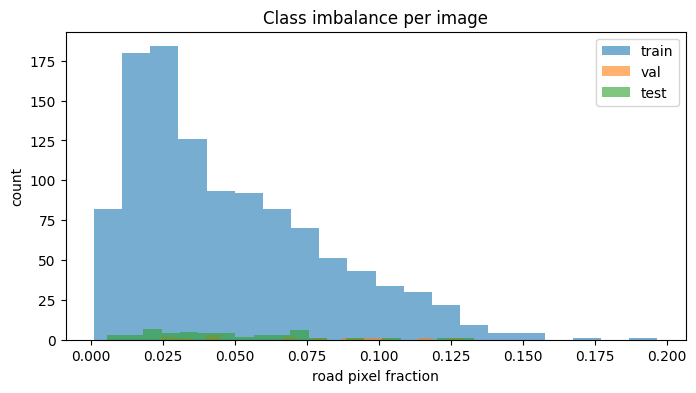

In [7]:
road_fracs = []
for split, (_, mask_dir) in splits.items():
    for fname in os.listdir(mask_dir):
        mask = cv2.cvtColor(cv2.imread(os.path.join(mask_dir, fname)), cv2.COLOR_BGR2RGB)
        road = (mask == class_rgb[1]).all(axis=-1)
        road_fracs.append({'split': split, 'road_frac': road.mean()})
frac_df = pd.DataFrame(road_fracs)
print(frac_df.groupby('split')['road_frac'].describe())
plt.figure(figsize=(8, 4))
for split in splits:
    plt.hist(frac_df[frac_df['split'] == split]['road_frac'], bins=20, alpha=0.6, label=split)
plt.xlabel('road pixel fraction')
plt.ylabel('count')
plt.title('Class imbalance per image')
plt.legend()
plt.show()

In [5]:
def visualize(**images):
    n_images = len(images)
    plt.figure(figsize=(20,8))
    for idx, (name, image) in enumerate(images.items()):
        plt.subplot(1, n_images, idx + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(name.title(), fontsize=20)
        plt.imshow(image)
    plt.show()

In [6]:
class RoadDataset(Dataset):
    def __init__(self, img_dir, mask_dir, class_rgb=class_rgb, augmentation=None):
        self.img_paths = [os.path.join(img_dir, img_id) for img_id in sorted(os.listdir(img_dir))]
        self.mask_paths = [os.path.join(mask_dir, mask_id) for mask_id in sorted(os.listdir(mask_dir))]
        self.class_rgb = class_rgb
        self.augmentation = augmentation

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, i):
        image = cv2.imread(self.img_paths[i], cv2.IMREAD_UNCHANGED)
        mask = cv2.imread(self.mask_paths[i], cv2.IMREAD_GRAYSCALE)
        
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask)
            
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
            
        return image, mask.float() / 255.0

In [7]:
IMG_SIZE = 512
BATCH_SIZE = 4

train_transform = A.Compose([
    A.RandomCrop(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Normalize(),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.CenterCrop(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2(),
])

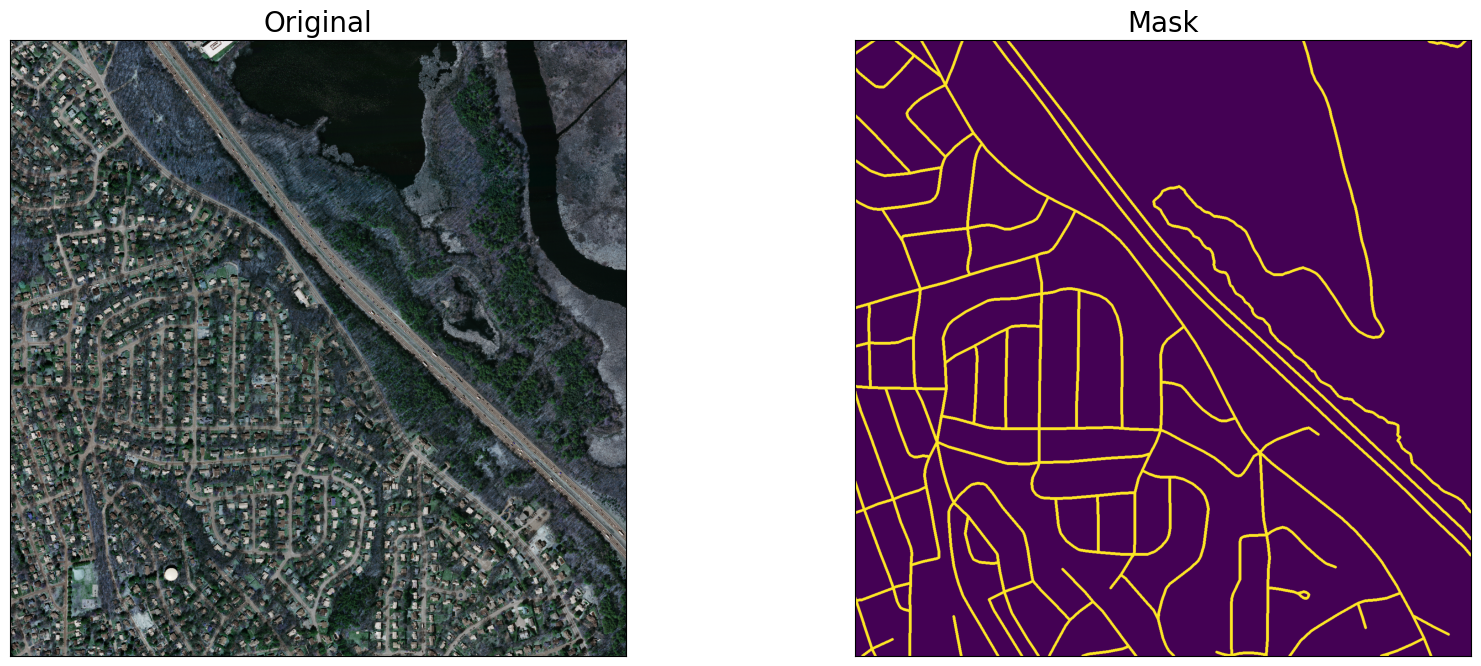

In [13]:
dataset = RoadDataset(x_train_dir, y_train_dir, class_rgb=class_rgb)
random_idx = random.randint(0, len(dataset)-1)
image, mask = dataset[random_idx]
visualize(original=image,mask=mask[0])

In [8]:
train_dataset = RoadDataset(x_train_dir, y_train_dir, augmentation=train_transform)
val_dataset = RoadDataset(x_valid_dir, y_valid_dir, augmentation=val_transform)
test_dataset = RoadDataset(x_test_dir, y_test_dir, augmentation=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)


In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)
        ch = in_channels
        for feat in features:
            self.downs.append(DoubleConv(ch, feat))
            ch = feat
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        for feat in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feat * 2, feat, 2, stride=2))
            self.ups.append(DoubleConv(feat * 2, feat))
        self.final = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skips[idx // 2]
            x = torch.cat([skip, x], dim=1)
            x = self.ups[idx + 1](x)
        return self.final(x)


In [10]:
def dice_coef(pred, target, eps=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    return ((2 * inter + eps) / (union + eps)).mean().item()

def iou_score(pred, target, eps=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - inter
    return ((inter + eps) / (union + eps)).mean().item()

class DiceLoss(nn.Module):
    def forward(self, logits, target):
        probs = torch.sigmoid(logits)
        inter = (probs * target).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        return 1 - ((2 * inter + 1e-6) / (union + 1e-6)).mean()

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    def forward(self, logits, target):
        return self.bce(logits, target) + self.dice(logits, target)

class FocalLoss(nn.Module):
    def forward(self, logits, target):
        bce = F.binary_cross_entropy_with_logits(logits, target, reduction='none')
        probs = torch.sigmoid(logits)
        pt = probs * target + (1 - probs) * (1 - target)
        return (0.75 * (1 - pt) ** 2 * bce).mean()

def evaluate(model, loader, criterion, device=device):
    model.eval()
    tot_loss, tot_iou, tot_dice = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        tot_loss += criterion(logits, y).item()
        tot_iou += iou_score(logits, y)
        tot_dice += dice_coef(logits, y)
    n = len(loader)
    return {'loss': tot_loss / n, 'iou': tot_iou / n, 'dice': tot_dice / n}

def train(model, train_loader, val_loader, epochs=20, lr=1e-4, device=device,
          optim=torch.optim.Adam, crit=BCEDiceLoss, name=None, **kwargs):
    model = model.to(device)
    optimizer = optim(model.parameters(), lr=lr, **kwargs)
    criterion = crit()
    history = []
    best_val = np.inf
    for epoch in range(epochs):
        train_loss = 0
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        val_res = evaluate(model, val_loader, criterion, device)
        history.append({'epoch': epoch+1, 'train_loss': train_loss, **val_res})
        if val_res['loss'] < best_val:
            best_val = val_res['loss']
            save_name = name or model.__class__.__name__
            torch.save(model.state_dict(), f'best{save_name}.pt')
        if epoch % 5 == 0:
            print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_res['loss']:.4f} | IoU: {val_res['iou']:.4f}")
    return history


In [24]:
print('U-Net Baseline')
print('-' * 60)
unet = UNet()
unet_history = train(unet, train_loader, val_loader, epochs=20, name='UNet')
unet.load_state_dict(torch.load('bestUNet.pt', map_location=device, weights_only=True))
unet_test = evaluate(unet, test_loader, BCEDiceLoss(), device)
print(f"Test IoU: {unet_test['iou']:.4f} | Dice: {unet_test['dice']:.4f}")


U-Net Baseline
------------------------------------------------------------
Epoch 1 | Train: 1.2463 | Val: 1.0159 | IoU: 0.4081
Epoch 6 | Train: 0.6881 | Val: 0.5063 | IoU: 0.5762
Epoch 11 | Train: 0.6111 | Val: 0.3922 | IoU: 0.6176
Epoch 16 | Train: 0.5914 | Val: 0.3690 | IoU: 0.6156
Test IoU: 0.6002 | Dice: 0.7235


In [ ]:
class ResUNet(nn.Module):
    # pretrained resnet50 encoder, unet decoder
    # enc channels: stem=64, layer1=256, layer2=512, layer3=1024, layer4=2048
    def __init__(self, out_channels=1):
        super().__init__()
        pretr = tvm.resnet50(weights=tvm.ResNet50_Weights.DEFAULT)
        self.enc0 = nn.Sequential(pretr.conv1, pretr.bn1, pretr.relu)  # (B,64,H/2,W/2)
        self.pool = pretr.maxpool
        self.enc1 = pretr.layer1   # (B,256,H/4,W/4)
        self.enc2 = pretr.layer2   # (B,512,H/8,W/8)
        self.enc3 = pretr.layer3   # (B,1024,H/16,W/16)
        self.enc4 = pretr.layer4   # (B,2048,H/32,W/32)
        # decoder: upsample -> concat skip -> doubleconv
        dec_cfg = [(2048,1024,1024,512),(512,256,512,256),(256,128,256,128),(128,64,64,64)]
        self.ups  = nn.ModuleList([nn.ConvTranspose2d(i, o, 2, stride=2) for i,o,_,_ in dec_cfg])
        self.decs = nn.ModuleList([DoubleConv(o+s, out) for _,o,s,out in dec_cfg])
        self.up0  = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec0 = DoubleConv(32, 32)
        self.final = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):              
        e0 = self.enc0(x)                          
        e1 = self.enc1(self.pool(e0))           
        e2 = self.enc2(e1)                         
        e3 = self.enc3(e2)                         
        e4 = self.enc4(e3)                         
        skips = [e3, e2, e1, e0]
        x = e4
        for up, dec, skip in zip(self.ups, self.decs, skips):
            x = dec(torch.cat([up(x), skip], dim=1))
        return self.final(self.dec0(self.up0(x)))

In [25]:
print('ResNet50 Encoder U-Net')
print('-'*60)
resunet = ResUNet()
resunet_hist = train(resunet, train_loader, val_loader, epochs=20, name='ResUNet')
resunet.load_state_dict(torch.load('bestResUNet.pt', map_location=device, weights_only=True))
resunet_test = evaluate(resunet, test_loader, BCEDiceLoss(), device)
print(f"Test IoU: {resunet_test['iou']:.4f} | Dice: {resunet_test['dice']:.4f}")

ResNet50 Encoder U-Net
------------------------------------------------------------
Epoch 1 | Train: 1.2840 | Val: 1.0484 | IoU: 0.5802
Epoch 6 | Train: 0.7683 | Val: 0.5931 | IoU: 0.5896
Epoch 11 | Train: 0.5907 | Val: 0.3916 | IoU: 0.6309
Epoch 16 | Train: 0.5534 | Val: 0.3606 | IoU: 0.6342
Test IoU: 0.5963 | Dice: 0.7161


In [11]:
class DeepLabV3(nn.Module):
    def __init__(self, out_channels=1):
        super().__init__()
        self.model = tvm.segmentation.deeplabv3_resnet50(weights=tvm.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT)
        self.model.classifier[4] = nn.Conv2d(256, out_channels, 1)
        self.model.aux_classifier = None
 
    def forward(self, x):
        return self.model(x)['out']  # (B,1,H,W)

In [14]:
print('DeepLabV3')
print('-' * 60)
deeplab = DeepLabV3()
deeplab_hist = train(deeplab, train_loader, val_loader, epochs=20, name='DeepLabV3')
deeplab.load_state_dict(torch.load('bestDeepLabV3.pt', map_location=device, weights_only=True))
deeplab_test = evaluate(deeplab, test_loader, BCEDiceLoss(), device)
print(f"Test IoU: {deeplab_test['iou']:.4f} | Dice: {deeplab_test['dice']:.4f}")

DeepLabV3
------------------------------------------------------------
Epoch 1 | Train: 1.1864 | Val: 1.0094 | IoU: 0.3612
Epoch 6 | Train: 0.6529 | Val: 0.4600 | IoU: 0.5424
Epoch 11 | Train: 0.6116 | Val: 0.4097 | IoU: 0.5808
Epoch 16 | Train: 0.6036 | Val: 0.3847 | IoU: 0.6050
Test IoU: 0.5894 | Dice: 0.7148


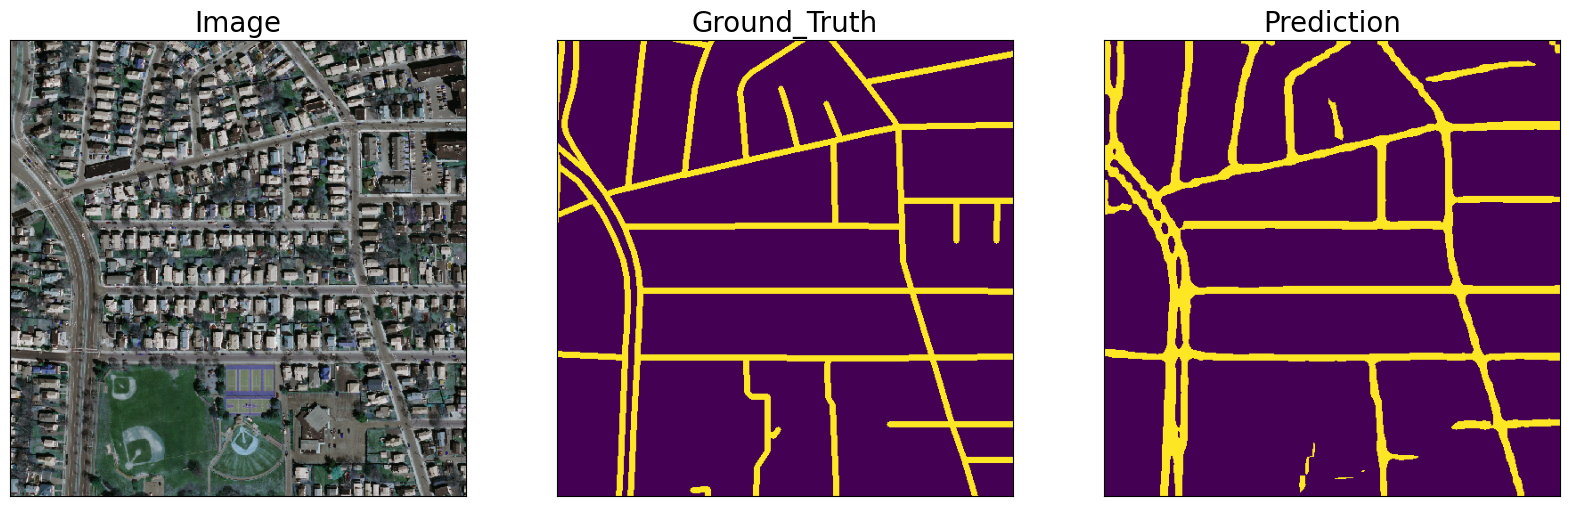

In [ ]:
@torch.no_grad()
def predict_sample(model, dataset):
    model.eval()
    img, mask = dataset[random.randint(0, len(dataset)-1)]
    pred = (torch.sigmoid(model(img.unsqueeze(0).to(device))) > 0.5).float().squeeze().cpu().numpy()
    img_vis = img.permute(1,2,0).numpy()
    img_vis = (img_vis * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])).clip(0,1)
    visualize(image=img_vis, ground_truth=mask.squeeze().numpy(), prediction=pred)

predict_sample(deeplab , test_dataset)